# Práctica: Análisis de Emociones y Sentimiento

**Asignatura:** NLP 2025-26  
**Pareja:** 14 - XiaoYong Wang y ChengHu Yang  
**Fecha:** 2026-04-13

In [8]:
!pip install pandas numpy scikit-learn matplotlib seaborn requests joblib python-dotenv openai

In [9]:

import os
import re
import json
import random
import string
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import requests
import joblib
from dotenv import load_dotenv
from openai import OpenAI

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, HashingVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
MODELS_DIR = Path("models")
FIG_DIR = Path("figures")

for d in [DATA_DIR, MODELS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EMOTIONS = ["anger", "anticipation", "disgust", "fear", "joy", "sadness", "surprise", "trust"]
POLARITY = ["negative", "positive"]


# Load .env from common candidate locations
_env_candidates = [
    Path.cwd() / '.env',
    Path('/Users/wxy/nlp/.env'),
]
for _env_path in _env_candidates:
    if _env_path.exists():
        load_dotenv(dotenv_path=_env_path, override=False)
        break


## 1) Carga del NRC EmoLex

Aquí cargamos el léxico NRC EmoLex.
Este recurso nos ayuda a elegir palabras semilla.
También nos muestra sus emociones y su polaridad.

El archivo se guarda en esta ruta:
- `data/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt`

Cada línea tiene este formato: `word	emotion	association`.

In [10]:
def load_emolex(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t", header=None, names=["word", "emotion", "association"])
    df = df[df["association"] == 1].copy()
    return df


def build_seed_table(emolex_df: pd.DataFrame) -> pd.DataFrame:
    grouped = emolex_df.groupby("word")["emotion"].apply(list).reset_index()

    def split_labels(labels):
        emo = sorted([x for x in labels if x in EMOTIONS])
        pol = sorted([x for x in labels if x in POLARITY])
        return emo, pol

    out = grouped.copy()
    out[["emotion_labels", "polarity_labels"]] = out["emotion"].apply(lambda x: pd.Series(split_labels(x)))
    out = out.drop(columns=["emotion"])
    return out

path = DATA_DIR / "NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"
emolex = load_emolex(path)
seeds = build_seed_table(emolex)
seeds.head()

,word,emotion_labels,polarity_labels
0,abacus,[trust],[]
1,abandon,"[fear, sadness]",[negative]
2,abandoned,"[anger, fear, sadness]",[negative]
3,abandonment,"[anger, fear, sadness, surprise]",[negative]
4,abba,[],[positive]


## 2) Dataset sintético con LLM

En esta parte usamos **LM Studio** y el modelo **`google/gemma-4-e2b`**.
El modelo genera frases en inglés a partir de palabras semilla de NRC EmoLex.

### LLM elegido
Elegimos Gemma 4 E2B porque funciona en local y da salida JSON válida.
También permite guardar checkpoints y repetir el proceso con control.

### Prompt utilizado
La versión final del prompt es **`v9-gemma-local-strict-json`**.
El prompt exacto está en la variable `USER_PROMPT_BATCH_TEMPLATE`.
También usamos un `SYSTEM_PROMPT` corto para pedir JSON válido.

### Restricciones
- una emoción principal por frase;
- una frase por cada palabra semilla;
- la frase debe incluir la palabra semilla;
- salida en JSON con esquema fijo;
- frases cortas y simples.

### Iteraciones
Sí, hicimos varias pruebas.
Al principio el modelo devolvía listas vacías o formatos inestables.
Después añadimos `json_schema` en la API.
Con eso la salida fue más estable.


### 2.1 Generación automática del dataset sintético a partir de EmoLex

Para ejecutar esta parte usamos la variable de entorno `LM_STUDIO_MODEL`.
En esta ejecución el valor es `google/gemma-4-e2b`.

Primero construimos un conjunto de semillas balanceado.
Tomamos **100 semillas por emoción**.
Por eso tenemos 8 clases y 800 frases en total.

La generación se hace por lotes pequeños.
Además, el código reintenta solo las semillas que faltan.
Así el proceso es más estable y más rápido.


In [11]:
import ast
import time

TARGET_EMOTIONS = ["anger", "anticipation", "disgust", "fear", "joy", "sadness", "surprise", "trust"]
PROMPT_VERSION = "v9-gemma-local-strict-json"

STYLE_REGISTER_WEIGHTS = {
    "modern_novel": 0.75,
    "high_modernist": 0.15,
    "classical_translation": 0.10,
}

LENGTH_BUCKET_RULES = {
    "short": "12-20 words; 0-1 subordinate clauses",
    "medium": "21-35 words; at least 1 subordinate clause",
    "long": "36-60 words; at least 2 subordinate clauses and grammatical clarity",
}

LENGTH_BUCKET_WEIGHTS = {
    "short": 0.20,
    "medium": 0.50,
    "long": 0.30,
}

DEFAULT_MODEL = "google/gemma-4-e2b"
DEFAULT_CHECKPOINT_DIR = DATA_DIR / "synthetic_checkpoints_gemma4_e2b_v2"
DEFAULT_OUTPUT_PATH = DATA_DIR / "synthetic_emotion_dataset_gemma4_e2b.csv"

SYSTEM_PROMPT = """You create high-quality synthetic NLP datasets.
Always follow JSON output rules exactly.
Return valid JSON only.
Do not explain your answer.
"""

def build_response_format(seeds: list[str], n_sentences: int) -> dict:
    return {
        "type": "json_schema",
        "json_schema": {
            "name": "synthetic_emotion_batch",
            "strict": True,
            "schema": {
                "type": "array",
                "minItems": len(seeds),
                "maxItems": len(seeds),
                "items": {
                    "type": "object",
                    "properties": {
                        "seed_word": {"type": "string", "enum": seeds},
                        "sentences": {
                            "type": "array",
                            "items": {"type": "string"},
                            "minItems": n_sentences,
                            "maxItems": n_sentences
                        }
                    },
                    "required": ["seed_word", "sentences"],
                    "additionalProperties": False
                }
            }
        }
    }

# Prompt mas estricto para reducir seeds omitidos, plantillas y fuga de palabras emocionales.
USER_PROMPT_BATCH_TEMPLATE = """Generate synthetic data for single-label emotion classification.

Target emotion: {emotion}
For EACH seed word below, generate exactly {n_sentences} short English sentence(s).

Hard rules:
- Return valid JSON only.
- Return one object for every seed word, in the same order.
- Each sentence must include the seed word exactly, or a simple inflected form.
- The dominant emotion must be {emotion}.
- Do not use the emotion label itself or close emotion words directly.
- Do not explain the word, define the word, or talk about the word abstractly.
- Do not use lists, dialogue, hashtags, or proper nouns.
- Use plain natural narrative English.
- Keep each sentence between 10 and 20 words.
- Make each sentence concrete and situational.
- Avoid patterns like 'made him feel', 'left her feeling', or dictionary-style definitions.

Seed words:
{seed_lines}

Return exactly this schema:
[
  {{"seed_word": "word1", "sentences": ["..."]}},
  {{"seed_word": "word2", "sentences": ["..."]}}
]
"""


def sample_from_weights(weight_map: dict) -> str:
    keys = list(weight_map.keys())
    probs = np.array(list(weight_map.values()), dtype=float)
    probs = probs / probs.sum()
    return str(np.random.choice(keys, p=probs))


def parse_label_list(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    s = str(x).strip()
    if not s:
        return []
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(i) for i in v]
    except Exception:
        pass
    return [i.strip() for i in s.split(',') if i.strip()]


def is_simple_seed(word: str) -> bool:
    word = str(word).lower().strip()
    if not re.fullmatch(r"[a-z]+", word):
        return False
    if not (4 <= len(word) <= 10):
        return False
    bad_suffixes = ("tion", "sion", "ment", "ness", "ism", "ist", "ship", "ity", "ence", "ance")
    if word.endswith(bad_suffixes):
        return False
    return True


def build_seed_pool(
    seed_df: pd.DataFrame,
    n_per_emotion: int = 80,
    min_len: int = 3,
    single_emotion_only: bool = True,
    prefer_simple_words: bool = True,
) -> dict:
    tmp = seed_df.copy()
    tmp['word'] = tmp['word'].astype(str).str.lower()
    tmp = tmp[tmp['word'].str.match(r"^[a-z][a-z'\-]*$", na=False)]
    tmp = tmp[tmp['word'].str.len() >= min_len]

    if 'emotion_labels' in tmp.columns:
        tmp['emotion_labels'] = tmp['emotion_labels'].apply(parse_label_list)

    strict_pool = tmp.copy()
    if 'emotion_labels' in strict_pool.columns and single_emotion_only:
        strict_pool = strict_pool[strict_pool['emotion_labels'].apply(lambda labels: len(labels) == 1)]

    pool = {}
    for emo in TARGET_EMOTIONS:
        if 'emotion_labels' in strict_pool.columns:
            strict_words = sorted(strict_pool[strict_pool['emotion_labels'].apply(lambda labels: emo in labels)]['word'].unique().tolist())
            broad_words = sorted(tmp[tmp['emotion_labels'].apply(lambda labels: emo in labels)]['word'].unique().tolist())
        else:
            strict_words = sorted(strict_pool[strict_pool['emotion'] == emo]['word'].unique().tolist())
            broad_words = sorted(tmp[tmp['emotion'] == emo]['word'].unique().tolist())

        primary = strict_words if strict_words else broad_words
        if prefer_simple_words:
            simple = [w for w in primary if is_simple_seed(w)]
            hard = [w for w in primary if w not in simple]
            ordered = simple + hard
        else:
            ordered = primary

        if len(ordered) < n_per_emotion:
            extras = [w for w in broad_words if w not in ordered]
            if prefer_simple_words:
                extras_simple = [w for w in extras if is_simple_seed(w)]
                extras_hard = [w for w in extras if w not in extras_simple]
                ordered = ordered + extras_simple + extras_hard
            else:
                ordered = ordered + extras

        selected = ordered[:n_per_emotion]
        pool[emo] = selected
    return pool


def make_uniform_seed_pool(seed_pool: dict, target_n: int | None = None) -> dict:
    if not seed_pool:
        return {}

    counts = {emotion: len(words) for emotion, words in seed_pool.items()}
    uniform_n = min(counts.values()) if target_n is None else int(target_n)

    lacking = [emotion for emotion, count in counts.items() if count < uniform_n]
    if lacking:
        raise ValueError(
            f"Some emotions do not have {uniform_n} seeds: "
            + ", ".join(f"{emotion}={counts[emotion]}" for emotion in lacking)
        )

    return {emotion: list(words[:uniform_n]) for emotion, words in seed_pool.items()}


def print_seed_pool_report(seed_pool: dict) -> None:
    counts = {emotion: len(words) for emotion, words in seed_pool.items()}
    report = pd.DataFrame(
        {"emotion": list(counts.keys()), "n_seeds": list(counts.values())}
    ).sort_values("emotion").reset_index(drop=True)
    display(report)
    print(f"uniform_seed_count = {report['n_seeds'].iloc[0]}")


def _chunks(seq, size):
    for i in range(0, len(seq), size):
        yield seq[i:i + size]


In [12]:
from pathlib import Path
import json
import pandas as pd

def ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)

def safe_read_csv(path: Path, **kwargs) -> pd.DataFrame:
    if path.exists() and path.stat().st_size > 1:
        try:
            return pd.read_csv(path, **kwargs)
        except pd.errors.EmptyDataError:
            pass
    return pd.DataFrame()

def save_json(obj, path: Path):
    ensure_dir(path.parent)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=True, indent=2)

def load_json(path: Path, default=None):
    if not path.exists():
        return default
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def plot_class_distribution(df: pd.DataFrame, title="Distribucion de clases"):
    plt.figure(figsize=(8, 4))
    order = sorted(df["primary_emotion"].unique())
    sns.countplot(data=df, x="primary_emotion", order=order)
    plt.title(title)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

def normalize_text(s: str) -> str:
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = s.translate(str.maketrans("", "", string.punctuation))
    return s


In [13]:
def call_local_chat(user_prompt: str, model: str = DEFAULT_MODEL, timeout: int = 180, max_tokens: int = 700, system_prompt: str = SYSTEM_PROMPT, response_format: dict | None = None) -> str:
    base_url = os.getenv("LM_STUDIO_BASE_URL", "http://127.0.0.1:1234/v1")
    api_key = os.getenv("LM_STUDIO_API_KEY", "lm-studio")
    model = model or os.getenv("LM_STUDIO_MODEL", DEFAULT_MODEL)

    client = OpenAI(base_url=base_url, api_key=api_key, timeout=timeout, max_retries=0)
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
        response_format=response_format,
        temperature=0.2,
        max_tokens=max_tokens,
    )
    return completion.choices[0].message.content


def parse_llm_json(raw_text: str):
    raw_text = raw_text.strip()
    try:
        return json.loads(raw_text)
    except Exception:
        pass
    m = re.search(r"\[.*\]", raw_text, flags=re.DOTALL)
    if m:
        try:
            return json.loads(m.group(0))
        except Exception:
            return None
    return None


def merge_emotion_raw_files(checkpoint_dir: Path, emotions=EMOTIONS) -> pd.DataFrame:
    frames = []
    for emotion in emotions:
        rows_path = checkpoint_dir / f"raw_{emotion}.csv"
        if rows_path.exists() and rows_path.stat().st_size > 1:
            try:
                frames.append(pd.read_csv(rows_path))
            except pd.errors.EmptyDataError:
                pass
    if not frames:
        return pd.DataFrame()
    merged = pd.concat(frames, ignore_index=True)
    merged["id"] = np.arange(len(merged))
    return merged


def generate_synthetic_dataset(
    seed_pool: dict,
    seeds_df: pd.DataFrame,
    llm_model: str = DEFAULT_MODEL,
    n_sentences_per_seed: int = 1,
    seeds_per_api_call: int = 2,
    max_retries: int = 3,
    sleep_sec: float = 0.4,
    request_timeout: int = 180,
    checkpoint_dir: Path = DATA_DIR / "synthetic_checkpoints",
    resume: bool = True,
) -> pd.DataFrame:
    """Varias semillas por llamada al modelo local. Checkpoint por emocion + seed individual."""
    ensure_dir(checkpoint_dir)

    seed_meta = seeds_df.copy()
    seed_meta["word"] = seed_meta["word"].astype(str).str.lower()
    if "emotion_labels" in seed_meta.columns:
        seed_meta["emotion_labels"] = seed_meta["emotion_labels"].apply(parse_label_list)
    if "polarity_labels" in seed_meta.columns:
        seed_meta["polarity_labels"] = seed_meta["polarity_labels"].apply(parse_label_list)
    seed_meta = seed_meta.drop_duplicates(subset=["word"]).set_index("word")

    for emotion, words in seed_pool.items():
        rows_path = checkpoint_dir / f"raw_{emotion}.csv"
        processed_path = checkpoint_dir / f"processed_seeds_{emotion}.json"

        existing_rows = safe_read_csv(rows_path)
        rows = existing_rows.to_dict(orient="records") if not existing_rows.empty else []
        processed = set(load_json(processed_path, default=[])) if resume else set()

        idx = len(rows)
        pending = [w for w in words if f"{emotion}::{w}" not in processed]

        for batch in _chunks(pending, max(1, int(seeds_per_api_call))):
            style_register = "plain_narrative"
            length_bucket = "short"
            length_rule = "10-22 words; simple syntax"

            batch = list(batch)
            collected_by_seed = {}
            remaining_batch = list(batch)
            last_err = None

            for attempt in range(1, max_retries + 1):
                if not remaining_batch:
                    break

                seed_lines = "\n".join(f"- {w}" for w in remaining_batch)
                user_prompt = USER_PROMPT_BATCH_TEMPLATE.format(
                    emotion=emotion,
                    style_register=style_register,
                    length_bucket=length_bucket,
                    length_rule=length_rule,
                    n_sentences=n_sentences_per_seed,
                    seed_lines=seed_lines,
                )

                parsed = None
                try:
                    raw = call_local_chat(
                        user_prompt,
                        model=llm_model,
                        timeout=request_timeout,
                        max_tokens=220 * max(1, len(remaining_batch)),
                        response_format=build_response_format(remaining_batch, n_sentences_per_seed),
                    )
                    parsed = parse_llm_json(raw)
                except Exception as e:
                    last_err = str(e)
                    print(f"[RETRY] emotion={emotion} seeds={remaining_batch} attempt={attempt}/{max_retries} err={last_err}")
                    time.sleep(sleep_sec * attempt)
                    continue

                if not isinstance(parsed, list):
                    print(f"[RETRY] emotion={emotion} seeds={remaining_batch} attempt={attempt}/{max_retries} err=non_list_json")
                    time.sleep(sleep_sec * attempt)
                    continue

                by_seed = {}
                for item in parsed:
                    if not isinstance(item, dict):
                        continue
                    sw = str(item.get("seed_word", "")).strip().lower()
                    sents = item.get("sentences")
                    if isinstance(sents, str):
                        sents = [sents]
                    if not isinstance(sents, list):
                        sents = []
                    sents = [str(s).strip() for s in sents if str(s).strip()]
                    if sw:
                        by_seed[sw] = sents

                for seed_word in list(remaining_batch):
                    sents = by_seed.get(seed_word.lower(), [])
                    if len(sents) >= n_sentences_per_seed:
                        collected_by_seed[seed_word.lower()] = sents[:n_sentences_per_seed]

                remaining_batch = [
                    seed_word for seed_word in remaining_batch
                    if seed_word.lower() not in collected_by_seed
                ]

                if remaining_batch:
                    print(f"[RETRY] emotion={emotion} missing={remaining_batch} attempt={attempt}/{max_retries}")
                    time.sleep(sleep_sec * attempt)

            batch_ok = len(remaining_batch) == 0
            if not batch_ok:
                print(f"[WARN] Incomplete batch emotion={emotion} seeds={remaining_batch} err={last_err}")

            for seed_word in batch:
                key = f"{emotion}::{seed_word}"
                sents = collected_by_seed.get(seed_word.lower(), [])
                if len(sents) < n_sentences_per_seed:
                    print(f"[WARN] Missing/short output seed={seed_word} emotion={emotion} got={len(sents)}")
                    continue

                emo_labels = []
                pol_labels = []
                if seed_word in seed_meta.index:
                    if "emotion_labels" in seed_meta.columns:
                        emo_labels = seed_meta.loc[seed_word, "emotion_labels"]
                    if "polarity_labels" in seed_meta.columns:
                        pol_labels = seed_meta.loc[seed_word, "polarity_labels"]

                for sent in sents[:n_sentences_per_seed]:
                    rows.append({
                        "id": idx,
                        "seed_word": seed_word,
                        "emotion_labels": emo_labels,
                        "polarity_labels": pol_labels,
                        "primary_emotion": emotion,
                        "generated_sentence": sent,
                        "style_register": style_register,
                        "length_bucket": length_bucket,
                        "length_rule": length_rule,
                        "language": "en",
                        "llm_model": llm_model,
                        "prompt_version": PROMPT_VERSION,
                        "generation_round": 1,
                    })
                    idx += 1

                processed.add(key)

            pd.DataFrame(rows).to_csv(rows_path, index=False)
            save_json(sorted(list(processed)), processed_path)
            if batch_ok:
                print(f"[CKPT][{emotion}] batch_seeds={len(batch)} rows={len(rows)} api_batches_done")
            time.sleep(sleep_sec)

        print(f"[DONE][{emotion}] rows={len(rows)} processed={len(processed)}")

    merged = merge_emotion_raw_files(checkpoint_dir)
    print(f"[MERGED] rows={len(merged)} from per-emotion files")
    return merged


,emotion,n_seeds
0,anger,100
1,anticipation,100
2,disgust,100
3,fear,100
4,joy,100
5,sadness,100
6,surprise,100
7,trust,100


uniform_seed_count = 100
[CKPT][anger] batch_seeds=2 rows=2 api_batches_done
[CKPT][anger] batch_seeds=2 rows=4 api_batches_done
[CKPT][anger] batch_seeds=2 rows=6 api_batches_done
[CKPT][anger] batch_seeds=2 rows=8 api_batches_done
[CKPT][anger] batch_seeds=2 rows=10 api_batches_done
[CKPT][anger] batch_seeds=2 rows=12 api_batches_done
[CKPT][anger] batch_seeds=2 rows=14 api_batches_done
[CKPT][anger] batch_seeds=2 rows=16 api_batches_done
[CKPT][anger] batch_seeds=2 rows=18 api_batches_done
[CKPT][anger] batch_seeds=2 rows=20 api_batches_done
[CKPT][anger] batch_seeds=2 rows=22 api_batches_done
[CKPT][anger] batch_seeds=2 rows=24 api_batches_done
[CKPT][anger] batch_seeds=2 rows=26 api_batches_done
[CKPT][anger] batch_seeds=2 rows=28 api_batches_done
[CKPT][anger] batch_seeds=2 rows=30 api_batches_done
[CKPT][anger] batch_seeds=2 rows=32 api_batches_done
[CKPT][anger] batch_seeds=2 rows=34 api_batches_done
[CKPT][anger] batch_seeds=2 rows=36 api_batches_done
[CKPT][anger] batch_seeds

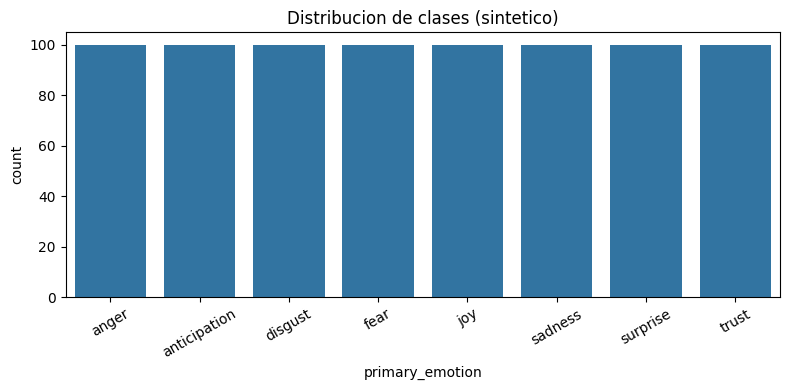

In [14]:
def normalize_text(s: str) -> str:
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = s.translate(str.maketrans("", "", string.punctuation))
    return s


def clean_synthetic_dataset(df: pd.DataFrame, min_words: int = 6, max_words: int = 60) -> pd.DataFrame:
    out = df.copy()
    out['generated_sentence'] = out['generated_sentence'].astype(str).str.strip()
    out = out[out['generated_sentence'] != ''].reset_index(drop=True)
    out['n_words'] = out['generated_sentence'].apply(lambda s: len(s.split()))

    out['emotion_labels'] = out['emotion_labels'].apply(parse_label_list).apply(lambda x: json.dumps(x, ensure_ascii=True))
    out['polarity_labels'] = out['polarity_labels'].apply(parse_label_list).apply(lambda x: json.dumps(x, ensure_ascii=True))

    out['id'] = np.arange(len(out))
    return out


def quick_dataset_report(df: pd.DataFrame):
    print(f"n_samples = {len(df)}")
    print(f"avg_sentence_len = {df['generated_sentence'].str.split().str.len().mean():.2f}")
    print("class_distribution:")
    print(df['primary_emotion'].value_counts().sort_index())
    dup = df['generated_sentence'].astype(str).apply(normalize_text).duplicated().mean()
    print(f"duplicate_ratio = {dup:.4f}")


# Paso 1: pool de seeds
# Primero construimos un pool amplio y luego lo recortamos a un numero identico
# de seeds por emocion. Asi garantizamos balance desde el origen.
seed_pool_raw = build_seed_pool(
    seeds,
    n_per_emotion=100,
    single_emotion_only=True,
    prefer_simple_words=True,
)

# Si target_n=None, usa automaticamente el minimo disponible entre emociones.
# Si quieres fijar un valor exacto, por ejemplo 50, cambia target_n=50.
seed_pool = make_uniform_seed_pool(seed_pool_raw, target_n=None)
print_seed_pool_report(seed_pool)

# Paso 2: LM Studio local — varias semillas por llamada (seeds_per_api_call)
# Usamos un checkpoint distinto para no mezclar esta version con la generacion anterior.
raw_synth = generate_synthetic_dataset(
    seed_pool=seed_pool,
    seeds_df=seeds,
    llm_model=os.getenv("LM_STUDIO_MODEL", DEFAULT_MODEL),
    n_sentences_per_seed=1,
    seeds_per_api_call=2,
    max_retries=3,
    sleep_sec=0.8,
    request_timeout=180,
    checkpoint_dir=DEFAULT_CHECKPOINT_DIR,
    resume=True,
)

# Paso 3: limpiar + exportar
synth = clean_synthetic_dataset(raw_synth)
out_path = DEFAULT_OUTPUT_PATH
synth.to_csv(out_path, index=False)
print(f"Dataset guardado en: {out_path}")
quick_dataset_report(synth)
plot_class_distribution(synth, title="Distribucion de clases (sintetico)")


### 2.2 Diagnóstico del dataset generado

El dataset final tiene **800 frases**.
Hay **100 frases por emoción**.
La distribución por clase está balanceada.
Pero las palabras semilla no vienen de una muestra aleatoria.
Primero filtramos las semillas y después tomamos las primeras en orden alfabético.
Por eso el número de frases por emoción es igual, pero la variedad léxica no es necesariamente igual.

No vemos duplicados exactos después de la normalización básica.
El ratio de duplicados es **0.0000**.
La longitud media es **11.01 palabras**.
El rango va de **8** a **25** palabras.

Creemos que el tamaño es suficiente para una práctica y para entrenar modelos clásicos.
Pero sigue siendo pequeño para novelas complejas.
Además, una selección alfabética puede dejar fuera otras semillas válidas de la misma emoción.
Si hubiera desbalance, una opción sería generar más frases para las clases pequeñas.
Otra opción sería hacer submuestreo o sobremuestreo.
También sería mejor seleccionar semillas con muestreo aleatorio o con más variedad semántica.


n_samples = 800
n_unique_sentences = 800
duplicate_ratio = 0.0000
avg_sentence_len = 11.01
sentence_len_range = [8, 25]
balance_ratio_min_max = 1.00
is_balanced = True

Valoración del tamaño: el dataset es suficiente para entrenar y comparar baselines clásicos en una práctica, pero sigue siendo pequeño para generalizar bien a literatura compleja.
Balance de clases: las clases están balanceadas o muy próximas al equilibrio.
Esto reduce el riesgo de que el clasificador favorezca sistemáticamente unas emociones sobre otras.
Duplicados: no se observan duplicados exactos tras la normalización básica.


,emotion,n_samples,percentage
0,anger,100,12.5
1,anticipation,100,12.5
2,disgust,100,12.5
3,fear,100,12.5
4,joy,100,12.5
5,sadness,100,12.5
6,surprise,100,12.5
7,trust,100,12.5


,primary_emotion,seed_word,generated_sentence
0,anger,disrespect,His constant disrespect made everyone furious ...
1,anger,hating,She felt hating the situation because everyone...
2,anticipation,extricate,She worked hard to extricate the trapped item ...
3,anticipation,letter,I look forward to receiving the important lett...
4,disgust,dung,He found the old dung piled up in the muddy co...
5,disgust,gutter,Filthy sludge flowed down the gutter onto the ...
6,fear,dictator,The dictator's heavy boot crushed the small pr...
7,fear,flying,The bird's frantic flying signaled immediate d...
8,joy,heartily,She cheered heartily for her friend's wonderfu...
9,joy,revel,We began to revel in the beautiful summer cele...


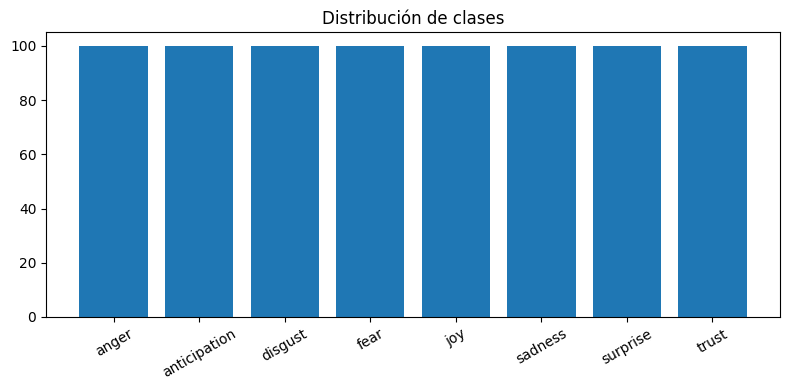

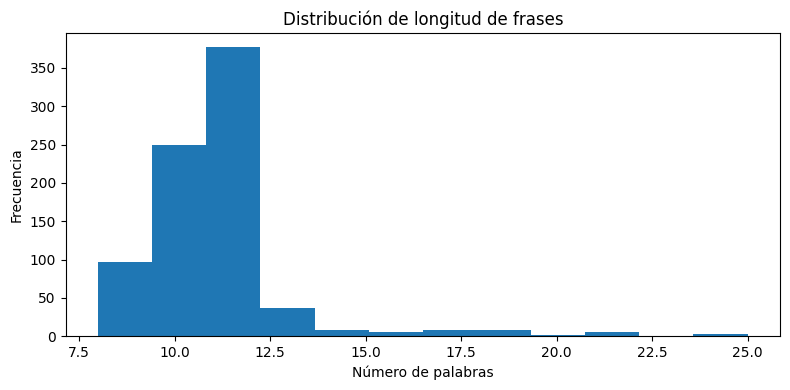

In [17]:
SYNTH_COLS = [
    "id", "seed_word", "emotion_labels", "polarity_labels", "primary_emotion",
    "generated_sentence", "language", "llm_model", "prompt_version", "generation_round"
]


def normalize_text(s: str) -> str:
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    s = s.translate(str.maketrans("", "", string.punctuation))
    return s


def load_synthetic_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    missing = [c for c in SYNTH_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en el dataset: {missing}")
    return df


def dataset_diagnostics(df: pd.DataFrame) -> dict:
    tmp = df.copy()
    tmp["sentence_len"] = tmp["generated_sentence"].astype(str).apply(lambda x: len(x.split()))
    tmp["norm_sentence"] = tmp["generated_sentence"].astype(str).apply(normalize_text)
    class_counts = tmp["primary_emotion"].value_counts().sort_index()
    class_dist = (class_counts / len(tmp)).round(4)
    dup_ratio = tmp["norm_sentence"].duplicated().mean()
    balance_ratio = float(class_counts.min() / class_counts.max()) if class_counts.max() else 0.0

    return {
        "n_samples": int(len(tmp)),
        "n_unique_sentences": int(tmp["norm_sentence"].nunique()),
        "dup_ratio": float(dup_ratio),
        "avg_sentence_len": float(tmp["sentence_len"].mean()),
        "min_sentence_len": int(tmp["sentence_len"].min()),
        "max_sentence_len": int(tmp["sentence_len"].max()),
        "balance_ratio": balance_ratio,
        "is_balanced": bool(class_counts.nunique() == 1),
        "class_counts": class_counts,
        "class_dist": class_dist,
    }


def class_balance_table(df: pd.DataFrame) -> pd.DataFrame:
    counts = df["primary_emotion"].value_counts().sort_index()
    perc = (counts / len(df) * 100).round(2)
    return pd.DataFrame({
        "emotion": counts.index,
        "n_samples": counts.values,
        "percentage": perc.values,
    })


def sample_examples_by_emotion(df: pd.DataFrame, n_per_emotion: int = 2, seed: int = RANDOM_STATE) -> pd.DataFrame:
    parts = []
    for _, part in df.groupby("primary_emotion", sort=True):
        parts.append(part.sample(min(len(part), n_per_emotion), random_state=seed))
    sample = pd.concat(parts).sort_values(["primary_emotion", "seed_word"])
    return sample[["primary_emotion", "seed_word", "generated_sentence"]].reset_index(drop=True)


def plot_class_distribution(df: pd.DataFrame, title="Distribución de clases"):
    plt.figure(figsize=(8, 4))
    counts = df["primary_emotion"].value_counts().sort_index()
    plt.bar(counts.index, counts.values)
    plt.title(title)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


def plot_sentence_length_distribution(df: pd.DataFrame):
    lengths = df["generated_sentence"].astype(str).apply(lambda x: len(x.split()))
    plt.figure(figsize=(8, 4))
    plt.hist(lengths, bins=12)
    plt.title("Distribución de longitud de frases")
    plt.xlabel("Número de palabras")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()


def print_dataset_assessment(info: dict):
    print(f"n_samples = {info['n_samples']}")
    print(f"n_unique_sentences = {info['n_unique_sentences']}")
    print(f"duplicate_ratio = {info['dup_ratio']:.4f}")
    print(f"avg_sentence_len = {info['avg_sentence_len']:.2f}")
    print(f"sentence_len_range = [{info['min_sentence_len']}, {info['max_sentence_len']}]")
    print(f"balance_ratio_min_max = {info['balance_ratio']:.2f}")
    print(f"is_balanced = {info['is_balanced']}")
    print()

    if info['n_samples'] < 1000:
        print("Valoración del tamaño: el dataset es suficiente para entrenar y comparar baselines clásicos en una práctica, pero sigue siendo pequeño para generalizar bien a literatura compleja.")
    else:
        print("Valoración del tamaño: el dataset es razonable para entrenar baselines clásicos y comparar configuraciones, aunque seguiría siendo recomendable ampliar y validar manualmente.")

    if info['is_balanced']:
        print("Balance de clases: las clases están balanceadas o muy próximas al equilibrio.")
        print("Esto reduce el riesgo de que el clasificador favorezca sistemáticamente unas emociones sobre otras.")
    else:
        print("Balance de clases: el dataset no está perfectamente balanceado.")
        print("Esto puede afectar al rendimiento, sobre todo en las emociones minoritarias.")
        print("Para mitigarlo se pueden generar más ejemplos de las clases minoritarias, aplicar sobremuestreo, submuestreo o usar pesos de clase.")

    if info['dup_ratio'] > 0.0:
        print("Duplicados: existen algunas frases repetidas tras normalización; conviene controlarlo para no inflar artificialmente el rendimiento.")
    else:
        print("Duplicados: no se observan duplicados exactos tras la normalización básica.")


synth = load_synthetic_dataset(DATA_DIR / "synthetic_emotion_dataset_gemma4_e2b.csv")
info = dataset_diagnostics(synth)
print_dataset_assessment(info)
display(class_balance_table(synth))
display(sample_examples_by_emotion(synth, n_per_emotion=2))
plot_class_distribution(synth)
plot_sentence_length_distribution(synth)


## 3) Entrenamiento y evaluación (2 algoritmos × 2 vectorizadores)

Usamos clasificación monolabel con la columna `primary_emotion`.

### Modelos elegidos
- **LogisticRegression**: es simple y fuerte para texto.
- **LinearSVC**: suele funcionar bien en clasificación de texto.

### Vectorizadores elegidos
- **TF-IDF**: da peso a palabras más informativas.
- **Count**: es una base simple.
- **Hashing**: usa menos memoria y es rápido.

Probamos cuatro combinaciones:
- `logreg + tfidf`
- `logreg + count`
- `linearsvc + tfidf`
- `linearsvc + hashing`

### Partición
Usamos 70% para entrenamiento, 15% para validación y 15% para test.
La partición es estratificada.

### Resultados
La mejor combinación en validación es **LinearSVC + Hashing**.
En validación obtiene **accuracy = 0.783** y **macro-F1 = 0.777**.
En test obtiene **accuracy = 0.750** y **macro-F1 = 0.751**.
Usamos macro-F1 como métrica principal porque todas las emociones tienen el mismo peso.


,model,vectorizer,val_accuracy,val_macro_f1,val_macro_precision,val_macro_recall
0,linearsvc,hashing,0.783,0.777,0.819,0.783
1,linearsvc,tfidf,0.767,0.762,0.775,0.767
2,logreg,tfidf,0.758,0.751,0.770,0.758
3,logreg,count,0.708,0.703,0.714,0.708


La mejor combinación en validación es linearsvc + hashing, con macro-F1=0.777 y accuracy=0.783. Dado que macro-F1 pondera por igual todas las clases, se toma como criterio principal de selección.


,precision,recall,f1-score,support
anger,0.706,0.800,0.750,15.000
anticipation,0.789,1.000,0.882,15.000
disgust,0.875,0.933,0.903,15.000
fear,1.000,0.400,0.571,15.000
joy,1.000,0.800,0.889,15.000
sadness,0.625,0.667,0.645,15.000
surprise,0.636,0.933,0.757,15.000
trust,0.917,0.733,0.815,15.000
accuracy,0.783,0.783,0.783,0.783
macro avg,0.819,0.783,0.777,120.000


Test accuracy = 0.750 | macro_precision = 0.757 | macro_recall = 0.750 | macro_f1 = 0.751


,precision,recall,f1-score,support
anger,0.824,0.933,0.875,15.00
anticipation,0.800,0.800,0.800,15.00
disgust,1.000,0.800,0.889,15.00
fear,0.562,0.600,0.581,15.00
joy,0.800,0.800,0.800,15.00
sadness,0.692,0.600,0.643,15.00
surprise,0.647,0.733,0.688,15.00
trust,0.733,0.733,0.733,15.00
accuracy,0.750,0.750,0.750,0.75
macro avg,0.757,0.750,0.751,120.00


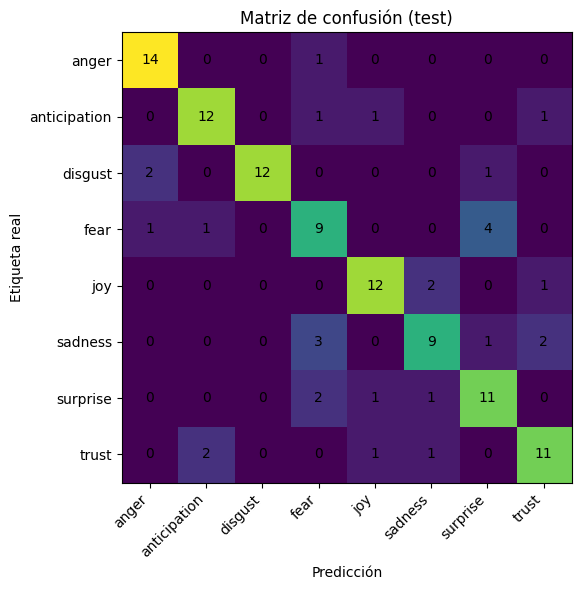

In [18]:
def build_vectorizers():
    return {
        "tfidf": TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=50000),
        "count": CountVectorizer(ngram_range=(1, 2), min_df=2, max_features=50000),
        "hashing": HashingVectorizer(ngram_range=(1, 2), n_features=2**18, alternate_sign=False),
    }


def build_models():
    return {
        "logreg": LogisticRegression(max_iter=1500, class_weight="balanced", random_state=RANDOM_STATE),
        "linearsvc": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
    }


def split_data(df: pd.DataFrame):
    X = df["generated_sentence"].astype(str).values
    y = df["primary_emotion"].astype(str).values

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def compute_metrics(y_true, y_pred) -> dict:
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "report": report,
    }


def train_and_evaluate(X_train, y_train, X_val, y_val, model_name, vectorizer_name):
    vec = build_vectorizers()[vectorizer_name]
    model = build_models()[model_name]

    pipe = Pipeline([
        ("vectorizer", vec),
        ("clf", model),
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_val)
    metrics = compute_metrics(y_val, pred)
    return pipe, metrics


def run_experiments(df: pd.DataFrame):
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)

    configs = [
        ("logreg", "tfidf"),
        ("logreg", "count"),
        ("linearsvc", "tfidf"),
        ("linearsvc", "hashing"),
    ]

    trained = {}
    reports = {}
    rows = []

    for m, v in configs:
        pipe, met = train_and_evaluate(X_train, y_train, X_val, y_val, m, v)
        key = f"{m}_{v}"
        trained[key] = pipe
        reports[key] = met["report"]
        rows.append({
            "model": m,
            "vectorizer": v,
            "val_accuracy": met["accuracy"],
            "val_macro_f1": met["macro_f1"],
            "val_macro_precision": met["macro_precision"],
            "val_macro_recall": met["macro_recall"],
        })

    results_df = pd.DataFrame(rows).sort_values(["val_macro_f1", "val_accuracy"], ascending=False).reset_index(drop=True)
    return trained, reports, results_df, (X_train, X_val, X_test, y_train, y_val, y_test)


def classification_report_table(report_dict: dict) -> pd.DataFrame:
    report_df = pd.DataFrame(report_dict).T
    keep_rows = [idx for idx in report_df.index if idx in EMOTIONS or idx in ["accuracy", "macro avg", "weighted avg"]]
    return report_df.loc[keep_rows].round(3)


def final_test_evaluation(best_pipe, X_test, y_test):
    labels = sorted(np.unique(y_test))
    pred = best_pipe.predict(X_test)
    metrics = compute_metrics(y_test, pred)
    print(
        f"Test accuracy = {metrics['accuracy']:.3f} | "
        f"macro_precision = {metrics['macro_precision']:.3f} | "
        f"macro_recall = {metrics['macro_recall']:.3f} | "
        f"macro_f1 = {metrics['macro_f1']:.3f}"
    )
    display(classification_report_table(metrics["report"]))

    cm = confusion_matrix(y_test, pred, labels=labels)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm)
    plt.title("Matriz de confusión (test)")
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")
    plt.xlabel("Predicción")
    plt.ylabel("Etiqueta real")
    plt.tight_layout()
    plt.show()
    return metrics, pred


def summarize_model_selection(results_df: pd.DataFrame) -> str:
    best_row = results_df.iloc[0]
    return (
        f"La mejor combinación en validación es {best_row['model']} + {best_row['vectorizer']}, "
        f"con macro-F1={best_row['val_macro_f1']:.3f} y accuracy={best_row['val_accuracy']:.3f}. "
        "Dado que macro-F1 pondera por igual todas las clases, se toma como criterio principal de selección."
    )


trained_models, report_tables, results_table, splits = run_experiments(synth)
display(results_table.round(3))
print(summarize_model_selection(results_table))

best_row = results_table.iloc[0]
best_model_name = f"{best_row['model']}_{best_row['vectorizer']}"
display(classification_report_table(report_tables[best_model_name]))

X_train, X_val, X_test, y_train, y_val, y_test = splits
test_metrics, test_predictions = final_test_evaluation(trained_models[best_model_name], X_test, y_test)


In [19]:
def save_pipeline(pipe, name: str):
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    out = MODELS_DIR / f"{name}.joblib"
    joblib.dump(pipe, out)
    return out


def load_pipeline(name: str):
    path = MODELS_DIR / f"{name}.joblib"
    if not path.exists():
        raise FileNotFoundError(f"Modelo no encontrado: {path}")
    return joblib.load(path)


required_names = ["trained_models", "best_model_name", "X_test"]
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(
        "Faltan variables del entrenamiento previo: "
        + ", ".join(missing_names)
        + ". Ejecuta primero la celda de entrenamiento y selección del mejor modelo."
    )

saved_paths = {}
for model_name, pipe in trained_models.items():
    saved_paths[model_name] = save_pipeline(pipe, model_name)

saved_models_df = pd.DataFrame({
    "model_name": list(saved_paths.keys()),
    "path": [str(path) for path in saved_paths.values()],
})
display(saved_models_df)

reloaded_best_model = load_pipeline(best_model_name)
demo_predictions = reloaded_best_model.predict(X_test[:5])
print("Modelo recargado correctamente:", best_model_name)
print("Predicciones de muestra tras recarga:", demo_predictions.tolist())

,model_name,path
0,logreg_tfidf,models/logreg_tfidf.joblib
1,logreg_count,models/logreg_count.joblib
2,linearsvc_tfidf,models/linearsvc_tfidf.joblib
3,linearsvc_hashing,models/linearsvc_hashing.joblib


Modelo recargado correctamente: linearsvc_hashing
Predicciones de muestra tras recarga: ['joy', 'anger', 'anger', 'anger', 'disgust']


## 4) Función de análisis emocional sobre texto libre

La función recibe un texto y un modelo entrenado.
Si el texto es largo, lo dividimos en bloques.
Después calculamos un perfil emocional por bloque.
Al final calculamos un perfil global del texto.

### Nivel de emoción
La salida es un diccionario.
Las claves son las ocho emociones del NRC.
Los valores son números entre 0 y 1.

Si el modelo tiene `predict_proba`, usamos la media de probabilidades.
Si no, usamos la frecuencia relativa de las etiquetas predichas.
Esta estrategia es simple y funciona bien para textos largos.


In [20]:
def split_into_blocks(text: str, block_size_words: int = 160):
    words = text.split()
    blocks = []
    for i in range(0, len(words), block_size_words):
        block = " ".join(words[i:i + block_size_words]).strip()
        if block:
            blocks.append(block)
    return blocks


def emotion_profile_for_text(text: str, pipe, emotions=EMOTIONS, block_size_words: int = 160):
    blocks = split_into_blocks(text, block_size_words=block_size_words)
    if not blocks:
        return {e: 0.0 for e in emotions}

    clf = pipe.named_steps["clf"]
    preds = pipe.predict(blocks)

    # Si el modelo ofrece probabilidades, se promedian por bloque; si no,
    # se usa la frecuencia relativa de las etiquetas predichas.
    if hasattr(clf, "predict_proba"):
        proba = pipe.predict_proba(blocks)
        labels = list(pipe.classes_)
        prof = {e: 0.0 for e in emotions}
        for j, label in enumerate(labels):
            if label in prof:
                prof[label] = float(np.mean(proba[:, j]))
        return prof

    counts = Counter(preds)
    total = len(preds)
    return {e: counts.get(e, 0) / total for e in emotions}


# --- Demo Tarea 3 ---
if "trained_models" not in globals() or "results_table" not in globals():
    raise RuntimeError(
        "Falta entrenar: ejecuta antes la celda que hace run_experiments(synth) "
        "y define trained_models / results_table."
    )

if "best_model_name" not in globals():
    _br = results_table.iloc[0]
    best_model_name = f"{_br['model']}_{_br['vectorizer']}"

pipe_demo = trained_models[best_model_name]
demo_text = "I feel afraid, but a small part of me still trusts that tomorrow may bring hope."
profile = emotion_profile_for_text(demo_text, pipe_demo)
print("Modelo:", best_model_name)
print("Perfil emocional de ejemplo:")
print(profile)


Modelo: linearsvc_hashing
Perfil emocional de ejemplo:
{'anger': 0.0, 'anticipation': 0.0, 'disgust': 1.0, 'fear': 0.0, 'joy': 0.0, 'sadness': 0.0, 'surprise': 0.0, 'trust': 0.0}


## 5) Descarga y análisis de novelas de Project Gutenberg

Descargamos automáticamente cinco novelas:
- *Crime and Punishment*
- *War and Peace*
- *Pride and Prejudice*
- *Frankenstein*
- *The Adventures of Sherlock Holmes*

Guardamos los resultados en un diccionario de diccionarios.
Cada novela tiene su `url`, su número de bloques, su perfil global y el detalle por bloque.

El proceso es simple:
1. descargar el texto;
2. limpiar cabecera y pie de Gutenberg;
3. dividir en bloques;
4. aplicar la función de análisis;
5. calcular un perfil global por novela.

Usamos el mejor modelo del apartado anterior.
Los resultados son útiles para comparar novelas, pero deben leerse con cuidado.


In [21]:
books = {
    "Crime and Punishment": "http://www.gutenberg.org/files/2554/2554-0.txt",
    "War and Peace": "http://www.gutenberg.org/files/2600/2600-0.txt",
    "Pride and Prejudice": "http://www.gutenberg.org/files/1342/1342-0.txt",
    "Frankenstein": "https://www.gutenberg.org/cache/epub/84/pg84.txt",
    "The Adventures of Sherlock Holmes": "http://www.gutenberg.org/files/1661/1661-0.txt",
    "Ulysses": "http://www.gutenberg.org/files/4300/4300-0.txt",
    "The Odyssey": "https://www.gutenberg.org/cache/epub/1727/pg1727.txt",
    "Moby Dick": "http://www.gutenberg.org/files/15/15-0.txt",
    "The Divine Comedy": "https://www.gutenberg.org/cache/epub/8800/pg8800.txt",
    "Critias": "https://www.gutenberg.org/cache/epub/1571/pg1571.txt",
}


def download_text(url: str):
    try:
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        return r.text
    except requests.RequestException as e:
        print(f"Error al descargar {url}: {e}")
        return None


def strip_gutenberg_header_footer(text: str) -> str:
    if not text:
        return ""

    start_patterns = [
        r"\*\*\* START OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*",
        r"\*\*\*START OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*",
    ]
    end_patterns = [
        r"\*\*\* END OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*",
        r"\*\*\*END OF (THE|THIS) PROJECT GUTENBERG EBOOK.*?\*\*\*",
    ]

    start_idx = 0
    for p in start_patterns:
        m = re.search(p, text, flags=re.IGNORECASE | re.DOTALL)
        if m:
            start_idx = m.end()
            break

    end_idx = len(text)
    for p in end_patterns:
        m = re.search(p, text, flags=re.IGNORECASE | re.DOTALL)
        if m:
            end_idx = m.start()
            break

    cleaned = text[start_idx:end_idx]
    cleaned = re.sub(r"\s+", " ", cleaned).strip()
    return cleaned


def analyze_books(book_dict: dict, pipe, n_books: int = 5, block_size_words: int = 160):
    results = {}
    selected = list(book_dict.items())[:n_books]

    for title, url in selected:
        raw = download_text(url)
        if not raw:
            continue
        cleaned = strip_gutenberg_header_footer(raw)
        blocks = split_into_blocks(cleaned, block_size_words=block_size_words)

        block_profiles = []
        for i, b in enumerate(blocks):
            prof = emotion_profile_for_text(b, pipe, block_size_words=block_size_words)
            block_profiles.append({"block_id": i, "text": b, **prof})

        block_df = pd.DataFrame(block_profiles)
        global_profile = block_df[EMOTIONS].mean().to_dict() if not block_df.empty else {e: 0.0 for e in EMOTIONS}

        results[title] = {
            "url": url,
            "n_blocks": len(blocks),
            "global_profile": global_profile,
            "blocks_df": block_df,
        }

    return results


book_results = analyze_books(books, trained_models[best_model_name], n_books=5)
print("Novelas analizadas:", list(book_results.keys()))


Novelas analizadas: ['Crime and Punishment', 'War and Peace', 'Pride and Prejudice', 'Frankenstein', 'The Adventures of Sherlock Holmes']


,book,n_blocks,top_emotion,anger,anticipation,disgust,fear,joy,sadness,surprise,trust
0,Crime and Punishment,1272,anger,0.506,0.051,0.006,0.002,0.006,0.028,0.252,0.149
1,Frankenstein,470,trust,0.206,0.123,0.049,0.002,0.000,0.032,0.111,0.477
2,Pride and Prejudice,796,trust,0.236,0.165,0.009,0.000,0.003,0.127,0.122,0.339
3,The Adventures of Sherlock Holmes,654,anger,0.298,0.162,0.014,0.005,0.000,0.014,0.283,0.225
4,War and Peace,3521,anger,0.467,0.163,0.027,0.008,0.004,0.057,0.132,0.143


Crime and Punishment: emoción dominante = anger | bloques = 1272
Frankenstein: emoción dominante = trust | bloques = 470
Pride and Prejudice: emoción dominante = trust | bloques = 796
The Adventures of Sherlock Holmes: emoción dominante = anger | bloques = 654
War and Peace: emoción dominante = anger | bloques = 3521


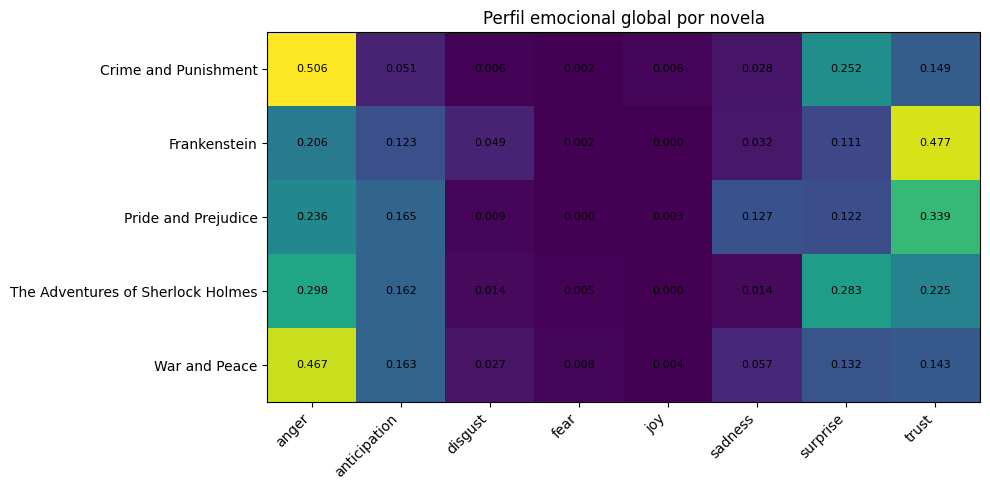

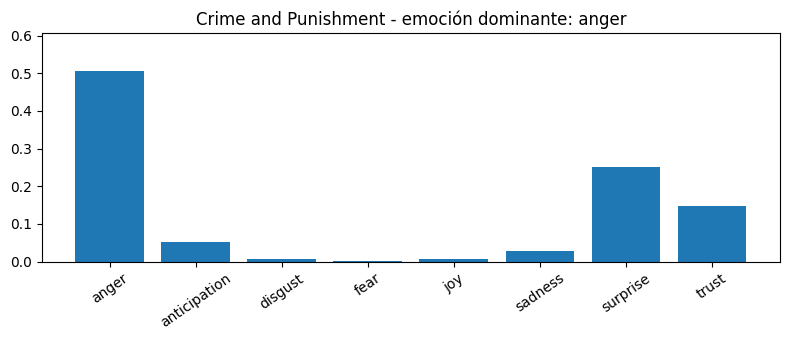

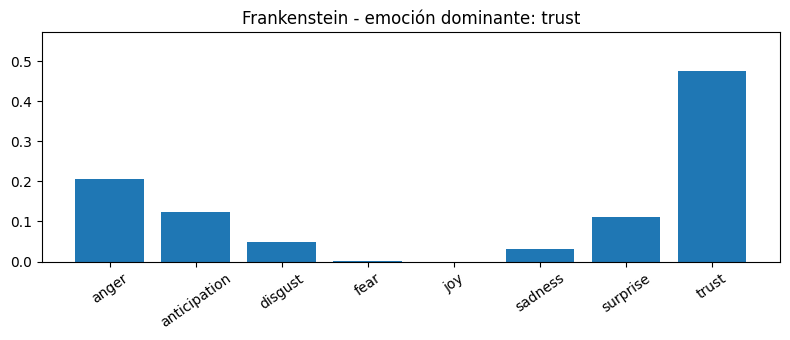

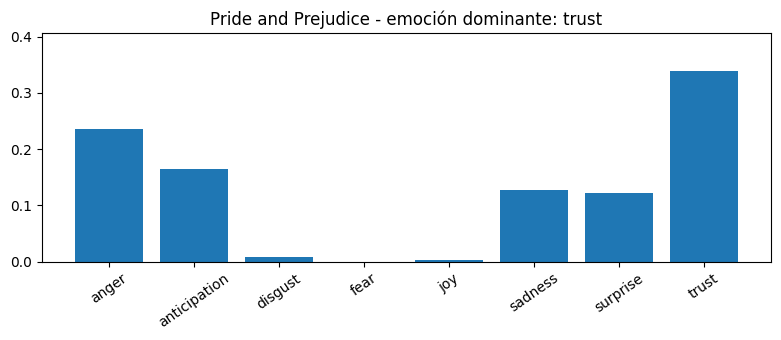

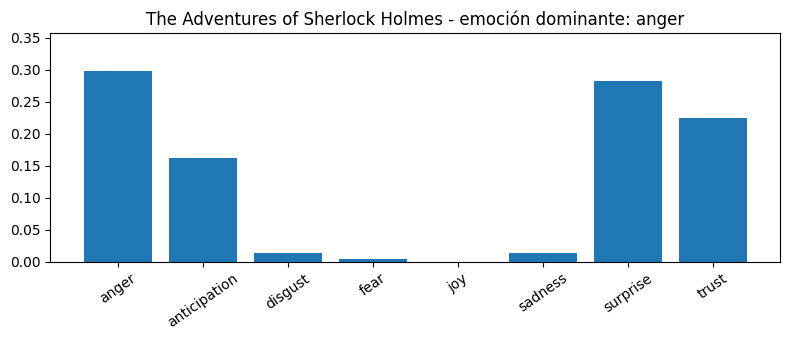

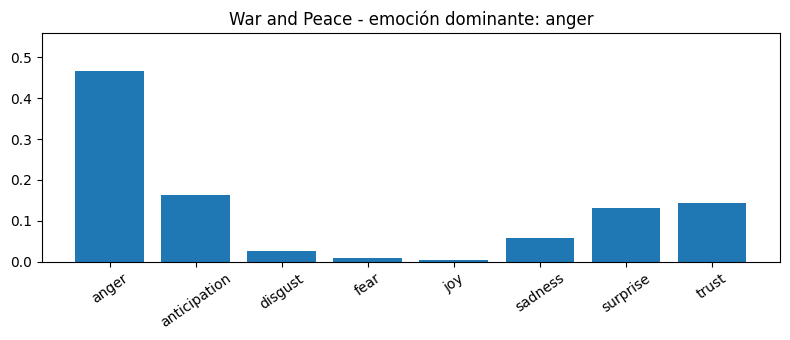

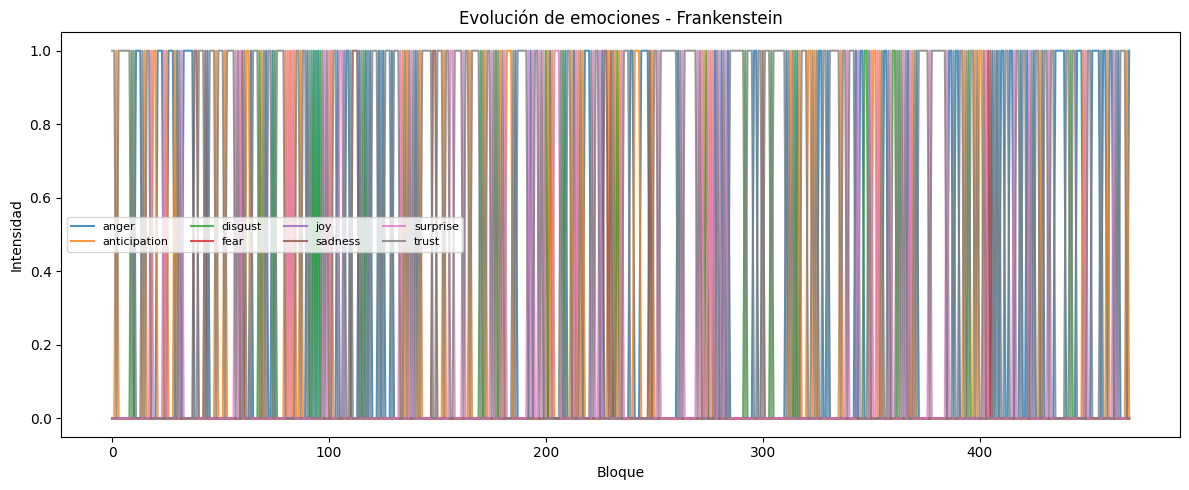

Bloques representativos en Crime and Punishment para la emoción anger:


,block_id,anger,text
0,0,1.0,CRIME AND PUNISHMENT By Fyodor Dostoevsky Tran...
1,1,1.0,"a revolutionist, Dostoevsky was one of a littl..."


In [22]:
def global_profile_table(book_results: dict) -> pd.DataFrame:
    rows = []
    for title, obj in book_results.items():
        top_emotion = max(obj["global_profile"], key=obj["global_profile"].get) if obj["global_profile"] else None
        row = {
            "book": title,
            "n_blocks": obj.get("n_blocks", 0),
            "top_emotion": top_emotion,
            **obj["global_profile"],
        }
        rows.append(row)
    if not rows:
        return pd.DataFrame(columns=["book", "n_blocks", "top_emotion"] + EMOTIONS)
    return pd.DataFrame(rows).sort_values("book").reset_index(drop=True)


def plot_book_profiles(df_profiles: pd.DataFrame):
    if df_profiles.empty:
        print("No hay resultados para visualizar.")
        return

    plt.figure(figsize=(10, 5))
    heat = df_profiles.set_index("book")[EMOTIONS]
    plt.imshow(heat.values, aspect="auto")
    plt.title("Perfil emocional global por novela")
    plt.xticks(range(len(EMOTIONS)), EMOTIONS, rotation=45, ha="right")
    plt.yticks(range(len(heat.index)), heat.index)
    for i in range(len(heat.index)):
        for j in range(len(EMOTIONS)):
            plt.text(j, i, f"{heat.values[i, j]:.3f}", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

    for _, row in df_profiles.iterrows():
        plt.figure(figsize=(8, 3.5))
        vals = [row[e] for e in EMOTIONS]
        plt.bar(EMOTIONS, vals)
        plt.xticks(rotation=35)
        plt.ylim(0, max(vals) * 1.2 if max(vals) > 0 else 1)
        plt.title(f"{row['book']} - emoción dominante: {row['top_emotion']}")
        plt.tight_layout()
        plt.show()


def plot_emotion_timeline(book_results: dict, book_name: str):
    if book_name not in book_results:
        print(f"{book_name} no encontrado")
        return
    df = book_results[book_name]["blocks_df"]
    if df.empty:
        print("Sin bloques para esta novela")
        return

    plt.figure(figsize=(12, 5))
    for emo in EMOTIONS:
        plt.plot(df["block_id"], df[emo], label=emo, alpha=0.8)
    plt.title(f"Evolución de emociones - {book_name}")
    plt.xlabel("Bloque")
    plt.ylabel("Intensidad")
    plt.legend(ncol=4, fontsize=8)
    plt.tight_layout()
    plt.show()


def representative_blocks(book_results: dict, book_name: str, emotion: str, top_k: int = 2) -> pd.DataFrame:
    if book_name not in book_results:
        return pd.DataFrame(columns=["block_id", emotion, "text"])
    df = book_results[book_name]["blocks_df"]
    if df.empty or emotion not in df.columns:
        return pd.DataFrame(columns=["block_id", emotion, "text"])
    cols = ["block_id", emotion, "text"]
    return df.nlargest(top_k, emotion)[cols].reset_index(drop=True)


def compare_books_text(df_profiles: pd.DataFrame):
    if df_profiles.empty:
        print("No hay perfiles para comparar.")
        return
    for _, row in df_profiles.iterrows():
        print(
            f"{row['book']}: emoción dominante = {row['top_emotion']} | "
            f"bloques = {row['n_blocks']}"
        )


profiles_df = global_profile_table(book_results)
display(profiles_df.round(3))
compare_books_text(profiles_df)
plot_book_profiles(profiles_df)
plot_emotion_timeline(book_results, "Frankenstein")

if not profiles_df.empty:
    example_book = profiles_df.iloc[0]["book"]
    example_emotion = profiles_df.iloc[0]["top_emotion"]
    print(f"Bloques representativos en {example_book} para la emoción {example_emotion}:")
    display(representative_blocks(book_results, example_book, example_emotion, top_k=2))


## 6) Discusión crítica y conclusiones

El sistema funciona, pero sus resultados tienen límites claros.
El dataset final tiene 800 frases, con 100 por emoción.
No hay duplicados exactos y la longitud media es 11.01 palabras.
Esto ayuda al entrenamiento, pero también simplifica mucho el problema.

### Lo que sí vemos en esta ejecución
- el dataset está balanceado;
- el mejor modelo es `LinearSVC + Hashing`;
- en validación obtiene macro-F1 = 0.777;
- en test obtiene macro-F1 = 0.751.

Estos resultados son aceptables para una práctica.
No son malos, pero tampoco son muy altos.
Además, algunas emociones son más difíciles que otras.
Por ejemplo, en validación la clase `fear` tiene un F1 más bajo que otras clases.
Eso sugiere que el modelo no separa todas las emociones con la misma claridad.

### Limitaciones reales del proyecto actual
- las frases de entrenamiento son sintéticas;
- muchas frases son cortas y directas;
- varias frases usan pistas léxicas muy visibles;
- el modelo aprende sobre frases simples, no sobre capítulos completos;
- las semillas se eligieron tras filtrar y cortar en orden alfabético.

Esto importa en las novelas.
Aunque tenemos 100 ejemplos por emoción, eso no significa que las semillas sean igual de representativas.
Una selección alfabética puede concentrar palabras parecidas y dejar fuera otras más útiles.
Una novela tiene contexto largo, cambios de tono, ironía y ambigüedad.
Nuestro sistema divide el texto en bloques fijos de 160 palabras.
Ese corte puede romper una escena o mezclar emociones diferentes en el mismo bloque.

También hay otra diferencia importante.
El entrenamiento usa frases cortas en inglés muy controladas.
Después aplicamos el modelo a novelas largas de Project Gutenberg.
Por eso el análisis final debe verse como una aproximación general.

### Conclusión
El pipeline cumple la práctica y permite comparar novelas de forma automática.
Es útil para ver tendencias globales.
Pero no ofrece una lectura literaria fina.
Los resultados son más fiables como señal exploratoria que como verdad exacta.
Para mejorar el sistema harían falta más datos, revisión humana y ejemplos menos artificiales.
